#Resume Screening using AI (NLP)

In [1]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/project-2026/proj-2/data/UpdatedResumeDataSet.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (962, 2)
Columns: ['Category', 'Resume']


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [2]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)         # URLs
    text = re.sub(r"\S+@\S+", " ", text)                # emails
    text = re.sub(r"[^a-z\s]", " ", text)               # keep letters/spaces
    text = re.sub(r"\s+", " ", text).strip()            # extra spaces
    return text

df["Resume_clean"] = df["Resume"].apply(clean_text)
df[["Category","Resume_clean"]].head()


,Category,Resume_clean
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may to may b e uit rgpv data...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills r python sap hana tableau sap hana sql ...
4,Data Science,education details mca ymcaust faridabad haryan...


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

job_description = """
Looking for a Machine Learning Engineer with Python, NLP, deep learning,
scikit-learn, PyTorch, model deployment, and feature engineering experience.
"""

job_clean = clean_text(job_description)

# TF-IDF on dataset resumes + job description
vectorizer = TfidfVectorizer(stop_words="english", max_features=10000, ngram_range=(1,2))

resume_tfidf = vectorizer.fit_transform(df["Resume_clean"])
job_tfidf = vectorizer.transform([job_clean])

scores = cosine_similarity(job_tfidf, resume_tfidf).flatten()

df_ranked = df.copy()
df_ranked["similarity_score"] = scores
top = df_ranked.sort_values("similarity_score", ascending=False).head(10)

top[["Category", "similarity_score", "Resume"]].head(10)


,Category,similarity_score,Resume
37,Data Science,0.404926,Education Details \r\n B.Tech Rayat and Bahr...
7,Data Science,0.404926,Education Details \r\n B.Tech Rayat and Bahr...
17,Data Science,0.404926,Education Details \r\n B.Tech Rayat and Bahr...
27,Data Science,0.404926,Education Details \r\n B.Tech Rayat and Bahr...
28,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
38,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
8,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
18,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
1,Data Science,0.195616,Education Details \r\nMay 2013 to May 2017 B.E...
21,Data Science,0.195616,Education Details \r\nMay 2013 to May 2017 B.E...


In [4]:
def snippet(text, n=280):
    text = str(text).replace("\n", " ")
    return (text[:n] + "...") if len(text) > n else text

top_out = top[["Category","similarity_score","Resume"]].copy()
top_out["Resume_snippet"] = top_out["Resume"].apply(snippet)
top_out = top_out.drop(columns=["Resume"])

top_out


,Category,similarity_score,Resume_snippet
37,Data Science,0.404926,Education Details \r B.Tech Rayat and Bahra...
7,Data Science,0.404926,Education Details \r B.Tech Rayat and Bahra...
17,Data Science,0.404926,Education Details \r B.Tech Rayat and Bahra...
27,Data Science,0.404926,Education Details \r B.Tech Rayat and Bahra...
28,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
38,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
8,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
18,Data Science,0.401276,Personal Skills â¢ Ability to quickly grasp t...
1,Data Science,0.195616,Education Details \r May 2013 to May 2017 B.E ...
21,Data Science,0.195616,Education Details \r May 2013 to May 2017 B.E ...


In [5]:
import os, joblib

BASE_DIR = "/content/drive/MyDrive/project-2026/proj-2"
MODEL_DIR = os.path.join(BASE_DIR, "models")
OUT_DIR = os.path.join(BASE_DIR, "outputs")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

joblib.dump(vectorizer, os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib"))
df_ranked.sort_values("similarity_score", ascending=False).to_csv(
    os.path.join(OUT_DIR, "ranked_resumes.csv"), index=False
)

print("Saved:")
print("-", os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib"))
print("-", os.path.join(OUT_DIR, "ranked_resumes.csv"))


Saved:
- /content/drive/MyDrive/project-2026/proj-2/models/tfidf_vectorizer.joblib
- /content/drive/MyDrive/project-2026/proj-2/outputs/ranked_resumes.csv


#Training Resume Category Classifier

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

X = df["Resume_clean"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=20000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=3000))
])

clf_pipeline.fit(X_train, y_train)

pred = clf_pipeline.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)
print(classification_report(y_test, pred))


Accuracy: 0.9948186528497409
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hadoop       

In [7]:
joblib.dump(clf_pipeline, os.path.join(MODEL_DIR, "resume_category_classifier.joblib"))
print("Saved:", os.path.join(MODEL_DIR, "resume_category_classifier.joblib"))


Saved: /content/drive/MyDrive/project-2026/proj-2/models/resume_category_classifier.joblib


In [8]:
sample_resume = """
Experienced Python developer with machine learning, NLP, scikit-learn, pandas,
and deploying models using FastAPI and Docker.
"""

print("Predicted category:", clf_pipeline.predict([clean_text(sample_resume)])[0])


Predicted category: Data Science


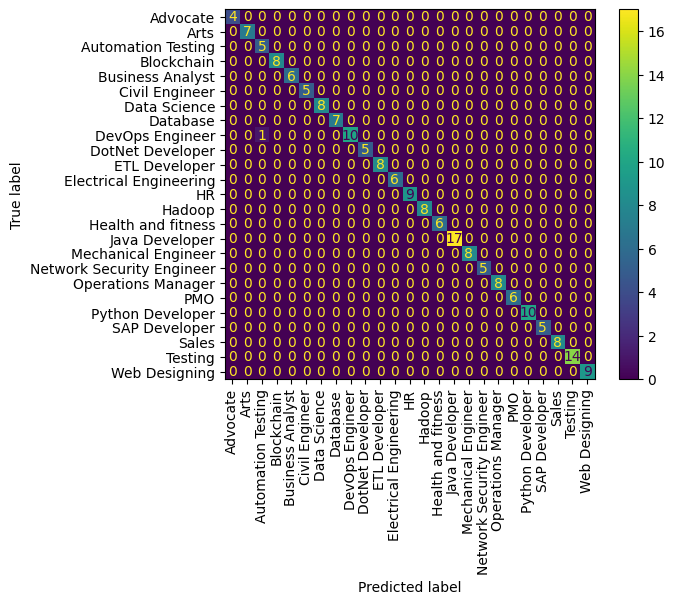

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred, xticks_rotation=90)
plt.show()
